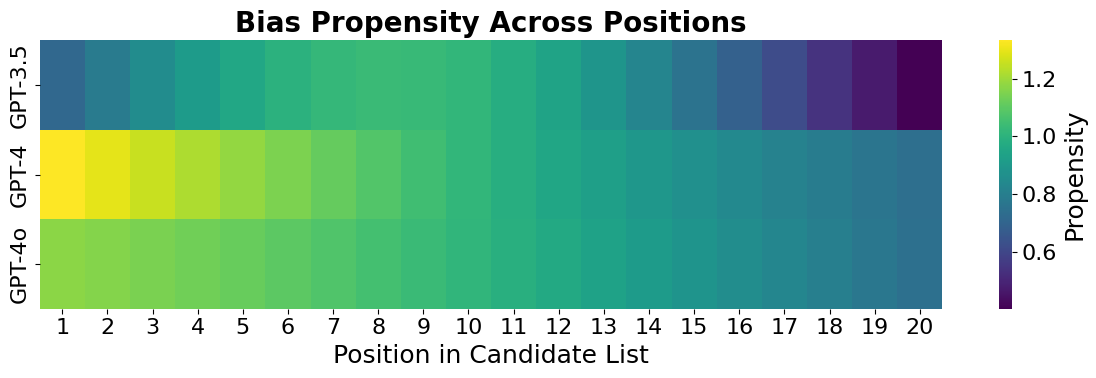

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bias scores
bias_scores = {
    "GPT-3.5": {"prim": -0.336, "rec": -0.912, "mid": 0.624},
    "GPT-4": {"prim": 0.288, "rec": -0.304, "mid": 0.008},
    "GPT-4o": {"prim": 0.160, "rec": -0.296, "mid": 0.068},
}

# Candidate list size
n = 20
positions = np.arange(1, n + 1)
x_vals = (positions - 1) / (n - 1)  # normalized positions

def compute_propensity(b_prim, b_rec, b_mid, x):
    return np.exp(
        b_prim * (1 - x) +
        b_rec * x +
        b_mid * (1 - 4 * (x - 0.5)**2)
    )

# Compute propensities for each model
propensities = {}
for model, biases in bias_scores.items():
    propensities[model] = compute_propensity(
        biases["prim"], biases["rec"], biases["mid"], x_vals
    )

# Set font sizes
plt.rcParams.update({'font.size': 14})  # Base font size

# Create a heatmap-style chart
plt.figure(figsize=(12, 4))  # Slightly larger figure to accommodate larger fonts
sns.heatmap(
    [propensities["GPT-3.5"], propensities["GPT-4"], propensities["GPT-4o"]],
    cmap="viridis",
    cbar_kws={"label": "Propensity"},  # Colorbar label
    xticklabels=positions,
    yticklabels=["GPT-3.5", "GPT-4", "GPT-4o"]
)

# Set font sizes for specific elements
plt.xlabel("Position in Candidate List", fontsize=18)
plt.title("Bias Propensity Across Positions", fontsize=20, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjust colorbar tick labels
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Propensity", fontsize=18)

plt.tight_layout()
plt.show()

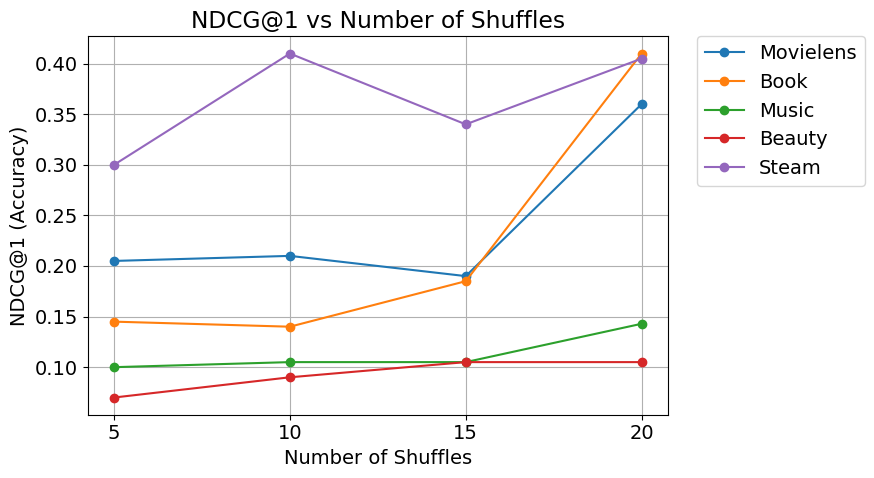

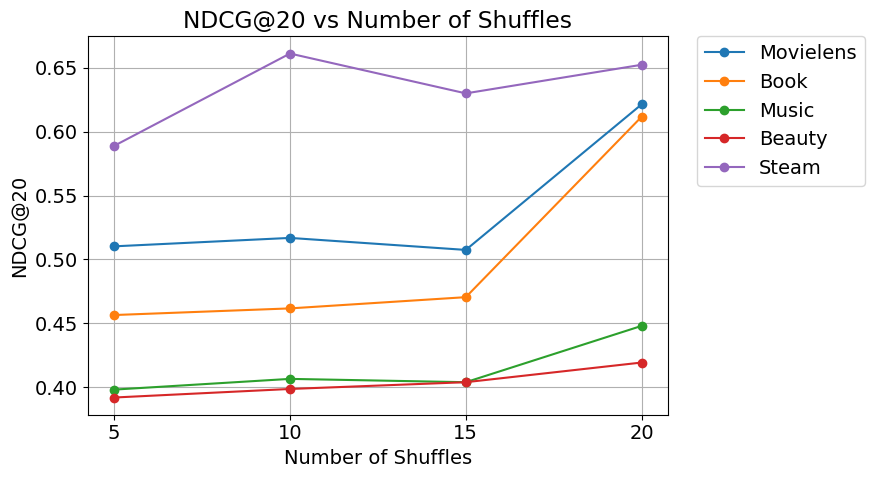

In [17]:
import matplotlib.pyplot as plt
import numpy as np

shuffles = [5, 10, 15, 20]  # x-axis (four points)

ndcg1 = {
    "movielens": [0.2050, 0.2100, 0.1900, 0.3600],
    "book":      [0.1450, 0.1400, 0.1850, 0.4100],
    "music":     [0.1000, 0.1050, 0.1050, 0.1429],
    "beauty":    [0.0700, 0.0900, 0.1050, 0.1050],
    "steam":     [0.3000, 0.4100, 0.3400, 0.4050],
}

ndcg20 = {
    "movielens": [0.5103, 0.5169, 0.5075, 0.6215],
    "book":      [0.4565, 0.4617, 0.4705, 0.6118],
    "music":     [0.3981, 0.4065, 0.4039, 0.4480],
    "beauty":    [0.3919, 0.3986, 0.4039, 0.4193],
    "steam":     [0.5890, 0.6613, 0.6301, 0.6525],
}

def plot_ndcg(metric_dict, ylabel, title):
    plt.figure(figsize=(7, 5))
    for dataset, values in metric_dict.items():
        plt.plot(shuffles, values, marker='o', label=dataset.capitalize())
        # Label at last data point
        # plt.text(
        #     shuffles[-1] + 2.5, values[-1],
        #     dataset.capitalize(),
        #     va='center', ha='left', fontsize=10
        # )
    plt.title(title)
    plt.xlabel("Number of Shuffles")
    plt.ylabel(ylabel)
    plt.xticks(shuffles)
    plt.grid(True)
    plt.tight_layout()
    # Optional: legend outside the plot area
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

plot_ndcg(ndcg1, "NDCG@1 (Accuracy)", "NDCG@1 vs Number of Shuffles")
plot_ndcg(ndcg20, "NDCG@20", "NDCG@20 vs Number of Shuffles")


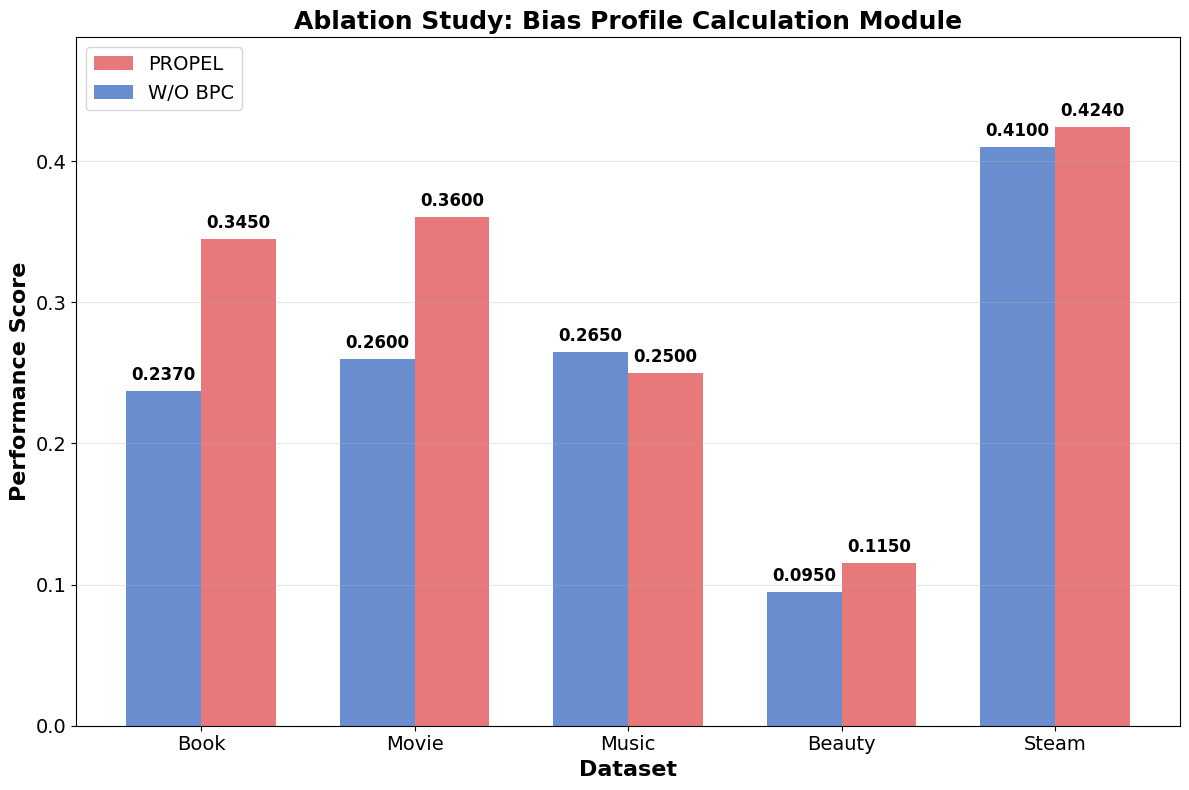

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the chart
datasets = ['Book', 'Movie', 'Music', 'Beauty', 'Steam']
propel_scores = [0.3450, 0.3600, 0.2500, 0.1150, 0.4240]
wo_baa_scores = [0.2370, 0.2600, 0.2650, 0.0950, 0.4100]

# Set up the bar chart
x = np.arange(len(datasets))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 8))  # Increased figure size to accommodate larger fonts

# Create bars
bars2 = ax.bar(x + width/2, propel_scores, width, label='PROPEL', color='#E15759', alpha=0.8)
bars1 = ax.bar(x - width/2, wo_baa_scores, width, label='W/O BPC', color='#4472C4', alpha=0.8)

# Customize the chart with larger fonts
ax.set_xlabel('Dataset', fontsize=16, fontweight='bold')  # Increased from 12 to 16
ax.set_ylabel('Performance Score', fontsize=16, fontweight='bold')  # Increased from 12 to 16
ax.set_title('Ablation Study: Bias Profile Calculation Module', fontsize=18, fontweight='bold')  # Increased from 14 to 18
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)  # Added fontsize=14 for x-tick labels
ax.legend(fontsize=14)  # Increased from 11 to 14

# Set y-tick font size
ax.tick_params(axis='y', labelsize=14)  # Added font size for y-tick labels

# Add value labels on bars
def add_value_labels(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)  # Increased from 9 to 12

add_value_labels(bars1, wo_baa_scores)
add_value_labels(bars2, propel_scores)



# Set y-axis limits and grid
ax.set_ylim(0, max(max(propel_scores), max(wo_baa_scores)) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

# Improve layout
plt.tight_layout()

# Display the chart
plt.show()

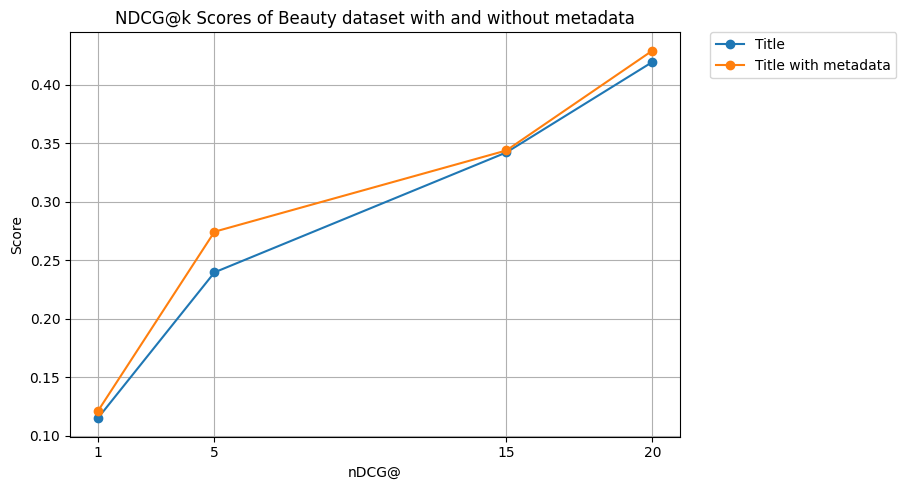

In [3]:
import matplotlib.pyplot as plt
import numpy as np

ndcg = [1, 5, 15, 20]  # x-axis (four points)

data = {
    "Title": [0.1150, 0.2397, 0.3421, 0.4193],
    "Title with metadata":      [0.1210, 0.2744, 0.3438, 0.4290],
}

def plot_ndcg(metric_dict, ylabel, title):
    plt.figure(figsize=(7, 5))
    for dataset, values in metric_dict.items():
        plt.plot(ndcg, values, marker='o', label=dataset.capitalize())
        # Label at last data point
        # plt.text(
        #     shuffles[-1] + 2.5, values[-1],
        #     dataset.capitalize(),
        #     va='center', ha='left', fontsize=10
        # )
    plt.title(title)
    plt.xlabel("nDCG@")
    plt.ylabel(ylabel)
    plt.xticks(ndcg)
    plt.grid(True)
    plt.tight_layout()
    # Optional: legend outside the plot area
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

plot_ndcg(data, "Score", "NDCG@k Scores of Beauty dataset with and without metadata")


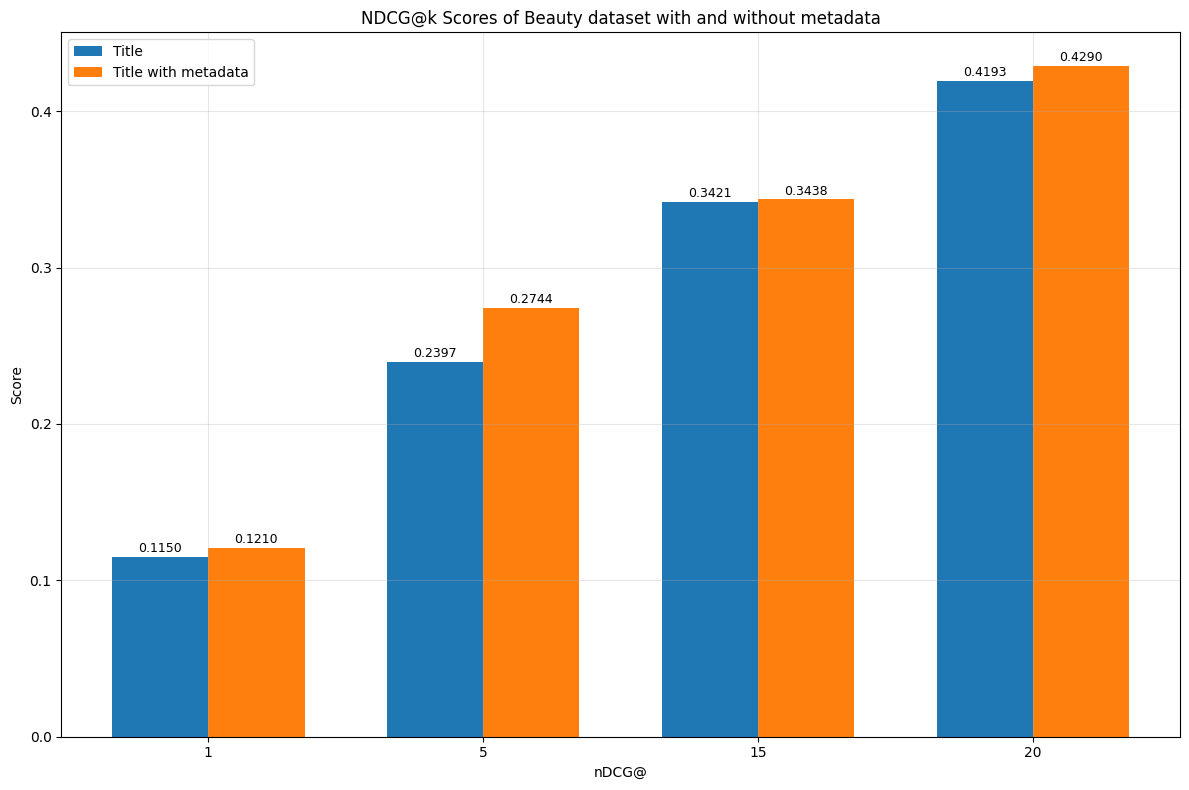

In [27]:
import matplotlib.pyplot as plt
import numpy as np

ndcg = [1, 5, 15, 20]  # x-axis (four points)
data = {
    "Title": [0.1150, 0.2397, 0.3421, 0.4193],
    "Title with metadata": [0.1210, 0.2744, 0.3438, 0.4290],
}

def plot_ndcg_bar(metric_dict, ylabel, title):
    plt.figure(figsize=(12, 8))
    
    # Set up bar positions
    x = np.arange(len(ndcg))  # the label locations
    width = 0.35  # the width of the bars
    
    # Create bars for each dataset
    datasets = list(metric_dict.keys())
    bars1 = plt.bar(x - width/2, metric_dict[datasets[0]], width, label=datasets[0])
    bars2 = plt.bar(x + width/2, metric_dict[datasets[1]], width, label=datasets[1])
    
    # Add value labels on top of bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.title(title)
    plt.xlabel("nDCG@")
    plt.ylabel(ylabel)
    plt.xticks(x, ndcg)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_ndcg_bar(data, "Score", "NDCG@k Scores of Beauty dataset with and without metadata")

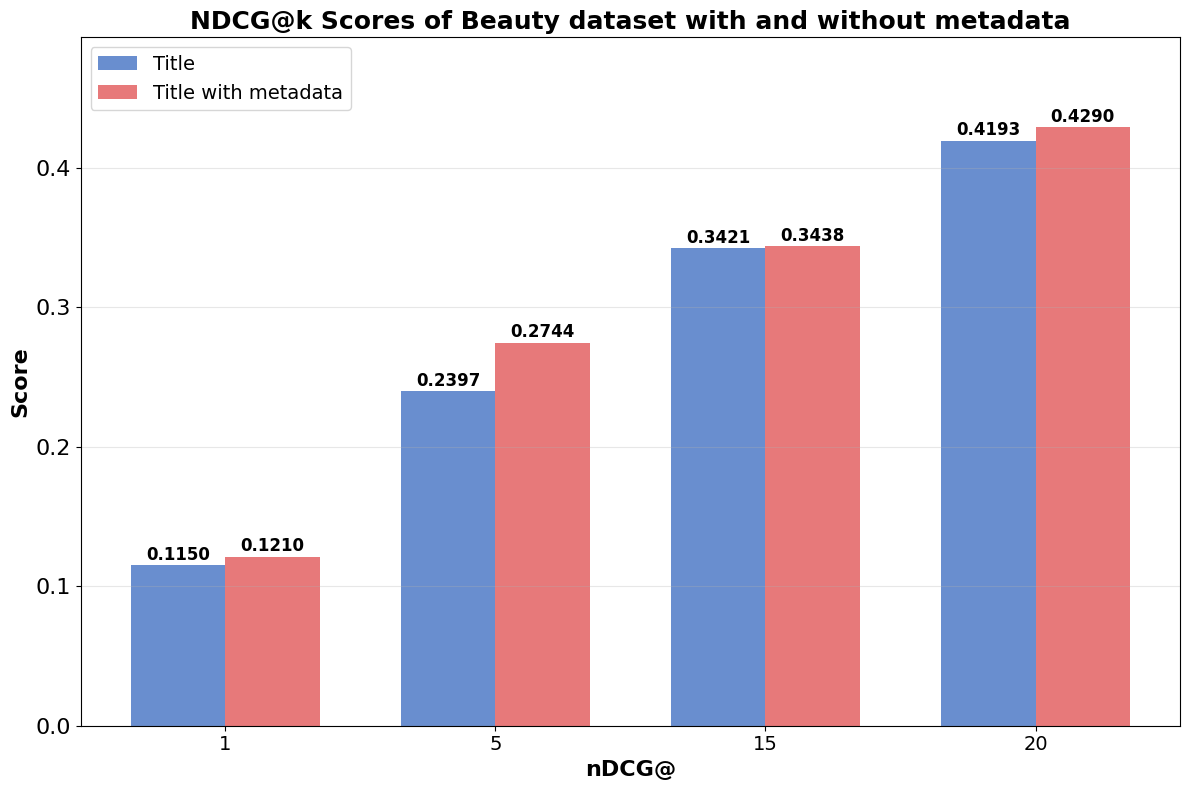

In [30]:
import matplotlib.pyplot as plt
import numpy as np

ndcg = [1, 5, 15, 20]  # x-axis (four points)
data = {
    "Title": [0.1150, 0.2397, 0.3421, 0.4193],
    "Title with metadata": [0.1210, 0.2744, 0.3438, 0.4290],
}

def plot_ndcg_bar(metric_dict, ylabel, title):
    plt.figure(figsize=(12, 8))
    
    # Set up bar positions
    x = np.arange(len(ndcg))  # the label locations
    width = 0.35  # the width of the bars
    
    # Create bars for each dataset
    datasets = list(metric_dict.keys())
    bars1 = plt.bar(x - width/2, metric_dict[datasets[0]], width, label=datasets[0], color='#4472C4', alpha=0.8)
    bars2 = plt.bar(x + width/2, metric_dict[datasets[1]], width, label=datasets[1], color='#E15759', alpha=0.8)
    
    # Add value labels on top of bars
    for bars in [bars2, bars1]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                    f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.title(title, fontsize=18, fontweight='bold')
    plt.xlabel("nDCG@", fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=16, fontweight='bold')
    plt.xticks(x, ndcg, fontsize=14)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14)
    plt.ylim(0, max(max(metric_dict[datasets[0]]), max(metric_dict[datasets[1]])) * 1.15)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

plot_ndcg_bar(data, "Score", "NDCG@k Scores of Beauty dataset with and without metadata")